# Amazon Scaping Laptops Data

In [1]:
# install beautifulsoup4 and requests
!pip install beautifulsoup4 requests

In [2]:
# import required libraries
import requests
from bs4 import BeautifulSoup
import re
import pandas as pd


In [3]:
# url of the page to be scraped
url ="https://www.amazon.in/s?k=laptops&crid=3O5DJEZW2W1BU&sprefix=lapto%2Caps%2C809&ref=nb_sb_noss_2"

In [4]:
# make header to mimic a browser visit
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/137.0.0.0 Safari/537.36",
    "Accept-Language": "en-US,en;q=0.9"
}

In [5]:
# check if the url is accessible
response = requests.get(url, headers=headers)
if response.status_code == 200:
    print("URL is accessible")
else:
    print("URL is not accessible")    

In [6]:
# check the response content
print(response.content)

In [7]:
# convert the response content to a BeautifulSoup object
soup = BeautifulSoup(response.content, "html.parser")
soup

In [8]:
# create the empty lists to store the scraped data
data = []
print("Data cleared")

In [9]:
for page in range(1,50):

    #paramters to be sent in the get request
    params = {
        "k": "laptops",
        "page": page
    }

    # get response from the server
    response = requests.get(url, headers=headers, params=params)

    # convert the response content to a BeautifulSoup object
    soup = BeautifulSoup(response.content, "html.parser")

    # find all the product items on the page using correct selector
    product_containers = soup.find_all("div", class_="s-result-item")

    # extract the required data from each product container
    for container in product_containers:

        # Step 1: Extract title from h2 tag
        h2_tag = container.find("h2")
        if not h2_tag:
            continue
        
        title = h2_tag.text.strip()
        
        # Skip if title is too short or is a header
        if len(title) < 10 or title in ["Results", "Trending now"]:
            continue

        # Step 2: Extract product price
        price_tag = container.find("span", class_="a-price-whole")
        price = price_tag.text.strip() if price_tag else "N/A"

        # Step 3: Extract product brand (first word)
        match = re.search(r"^([A-Za-z]+)", title)
        brand = match.group(1) if match else "Unknown"

        # Step 4 : Extract the ram form the title using regex GB,ram DDR LPDDR
        match = re.search(r"(\d+GB|RAM\s*(\d+GB)?|DDR\d?\s*(\d+GB)?|LPDDR\d?\s*(\d+GB)?)", title, re.IGNORECASE)
        ram = match.group(1) if match else "N/A"

        # Step 5 : Extract the SSD storage from the title using reges
        match = re.search(r"(\d+)\s*(GB|TB)\s*(?:SSD|Storage|HDD)", title, re.IGNORECASE)
        ssd_storage = f"{match.group(1)}{match.group(2)}" if match else "N/A"
        
        #Step 6 : Extract the Color from the title using regex
        match = re.search(r"\b(Black|White|Silver|Gray|Grey|Red|Blue|Green|Yellow|Pink|Purple|Gold|Bronze|Rose Gold|Indigo|Glacier)\b", title, re.IGNORECASE)
        color = match.group(1) if match else "N/A"

        # Step 7: Extract the processor (Intel, AMD, Apple M/A chip, Snapdragon, MediaTek, etc)
        processor = "N/A"
        # Try to match Apple M series (M1, M2, M3, M4, M5, etc.)
        match = re.search(r"Apple\s+M(\d+)", title, re.IGNORECASE)
        if match:
            processor = f"Apple M{match.group(1)}"
        else:
            # Try to match Apple A series (A18, A17, A16, etc.)
            match = re.search(r"Apple\s+A(\d+)", title, re.IGNORECASE)
            if match:
                processor = f"Apple A{match.group(1)}"
            else:
                # Try other processor keywords
                processor_keywords = ["Intel", "AMD", "Snapdragon", "MediaTek", "Celeron"]
                for keyword in processor_keywords:
                    if re.search(rf"\b{keyword}\b", title, re.IGNORECASE):
                        processor = keyword
                        break
        
        # Step 8: Extract the OS from the title using regex
        os = "N/A"
        # Check for MacBook/macOS first (Apple specific)
        if re.search(r"\b(MacBook|macOS|Mac OS)\b", title, re.IGNORECASE):
            os = "MacOS"
        # Check for Apple processors (M or A series means MacOS)
        elif re.search(r"\bApple\s+[MA]\d+\b", title, re.IGNORECASE):
            os = "MacOS"
        # Check for Windows variations
        elif re.search(r"\b(Windows|Win\s*11|Win11|Win\s*10|Win10)\b", title, re.IGNORECASE):
            os = "Windows"
        # Check for other OS keywords
        else:
            OS_keywords = ["Linux", "Chrome OS", "Android", "iOS"]
            for keyword in OS_keywords:
                if re.search(rf"\b{keyword}\b", title, re.IGNORECASE):
                    os = keyword
                    break
            
        # Step 9: Extract the Rating from the container
        rating = "N/A"
        # Try multiple methods to find rating
        # Method 1: Look for i-star span
        rating_span = container.find("span", class_=lambda x: x and "i-star" in str(x).lower() if x else False)
        
        # Method 2: Look for aria-label attribute with rating
        if not rating_span:
            rating_span = container.find("span", {"aria-label": lambda x: x and "out of 5" in str(x).lower() if x else False})
        
        # Method 3: Look for a-icon-star class
        if not rating_span:
            rating_span = container.find("i", class_=lambda x: x and "a-icon-star" in str(x).lower() if x else False)
        
        if rating_span:
            # Try to get rating from aria-label
            aria_label = rating_span.get("aria-label")
            if aria_label:
                match = re.search(r"(\d+\.?\d*)\s*out of 5", aria_label)
                if match:
                    rating = match.group(1)
            else:
                # Try to get from text
                rating_text = rating_span.text.strip() if rating_span else ""
                match = re.search(r"(\d+\.?\d*)", rating_text)
                if match:
                    rating = match.group(1) 


        # Append the extracted data to the list
        data.append({
            "title": title,
            "price": price,
            'brand' : brand,
            'ram' : ram,
            'ssd_storage' : ssd_storage,
            'color' : color,
            'processor' : processor,
            'os' : os,
            'rating' : rating
        })

print("Total items scraped:", len(data))


In [10]:
# print the scraped data in a structured format
for item in data:
    print(f"Title: {item['title']}")
    print(f"Price: {item['price']}")
    print(f"Brand: {item['brand']}")
    print(f"RAM: {item['ram']}")
    print(f"SSD Storage: {item['ssd_storage']}")
    print(f"Color: {item['color']}")
    print(f"Processor: {item['processor']}")
    print(f"OS: {item['os']}")
    print(f"Rating: {item['rating']}")
    print("-" * 40)

In [11]:
# make the dataframe from the scraped data
df = pd.DataFrame(data)
df.head()

In [ ]:
# saved dataset to csv file
df.to_csv("amazon_laptops.csv", index=False)

In [6]:
# 

df  = pd.read_csv("E:\\AI_Project\\Laptop_Recomandation\\Datasets\\amazon_laptops.csv")
df.head()

,Price,Brand,RAM,SSD_Storage,Color,Processor,OS,Rating
0,"53,990",Acer,12GB,512.0,Silver,Intel,Windows,4.0
1,"79,990",Acer,16GB,512.0,Grey,NaN,Windows,NaN
2,"45,490",Dell,8GB,NaN,Black,Intel,Windows,4.1
3,"51,990",HP,8GB,512.0,Silver,Intel,Windows,4.1
4,"53,990",ASUS,8GB,NaN,Blue,Intel,Windows,NaN


# Data Preprocessing on the scrap data

In [113]:
# check the info of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1069 entries, 0 to 1068
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Price        921 non-null    object 
 1   Brand        1069 non-null   object 
 2   RAM          789 non-null    object 
 3   SSD_Storage  744 non-null    float64
 4   Color        740 non-null    object 
 5   Processor    704 non-null    object 
 6   OS           795 non-null    object 
 7   Rating       838 non-null    float64
dtypes: float64(2), object(6)
memory usage: 66.9+ KB


In [7]:
# check the shape of the dataframe
df.shape

(1069, 8)

In [8]:
# check the missing values in the dataframe
df.isnull().sum()

Price          148
Brand            0
RAM            280
SSD_Storage    325
Color          329
Processor      365
OS             274
Rating         231
dtype: int64

In [9]:
# replace all N/A values with NaN
df.replace("N/A", pd.NA, inplace=True)

In [10]:
# check missing value 
df.isnull().sum()

Price          148
Brand            0
RAM            280
SSD_Storage    325
Color          329
Processor      365
OS             274
Rating         231
dtype: int64

In [11]:
df.head()

,Price,Brand,RAM,SSD_Storage,Color,Processor,OS,Rating
0,"53,990",Acer,12GB,512.0,Silver,Intel,Windows,4.0
1,"79,990",Acer,16GB,512.0,Grey,NaN,Windows,NaN
2,"45,490",Dell,8GB,NaN,Black,Intel,Windows,4.1
3,"51,990",HP,8GB,512.0,Silver,Intel,Windows,4.1
4,"53,990",ASUS,8GB,NaN,Blue,Intel,Windows,NaN


In [12]:
# all columns are first letter title 
df.columns = df.columns.str.title()

In [13]:
df.head()

,Price,Brand,Ram,Ssd_Storage,Color,Processor,Os,Rating
0,"53,990",Acer,12GB,512.0,Silver,Intel,Windows,4.0
1,"79,990",Acer,16GB,512.0,Grey,NaN,Windows,NaN
2,"45,490",Dell,8GB,NaN,Black,Intel,Windows,4.1
3,"51,990",HP,8GB,512.0,Silver,Intel,Windows,4.1
4,"53,990",ASUS,8GB,NaN,Blue,Intel,Windows,NaN


In [14]:
# Rename multiple columns
df = df.rename(columns = {'Ram' : 'RAM', 'Ssd_Storage' : 'SSD_Storage', 'Os' : 'OS',})

In [15]:
df.head()

,Price,Brand,RAM,SSD_Storage,Color,Processor,OS,Rating
0,"53,990",Acer,12GB,512.0,Silver,Intel,Windows,4.0
1,"79,990",Acer,16GB,512.0,Grey,NaN,Windows,NaN
2,"45,490",Dell,8GB,NaN,Black,Intel,Windows,4.1
3,"51,990",HP,8GB,512.0,Silver,Intel,Windows,4.1
4,"53,990",ASUS,8GB,NaN,Blue,Intel,Windows,NaN


In [16]:
df.head()

,Price,Brand,RAM,SSD_Storage,Color,Processor,OS,Rating
0,"53,990",Acer,12GB,512.0,Silver,Intel,Windows,4.0
1,"79,990",Acer,16GB,512.0,Grey,NaN,Windows,NaN
2,"45,490",Dell,8GB,NaN,Black,Intel,Windows,4.1
3,"51,990",HP,8GB,512.0,Silver,Intel,Windows,4.1
4,"53,990",ASUS,8GB,NaN,Blue,Intel,Windows,NaN


In [17]:
# handled the SSD storage column 

# replace the 1TB with 1024GB in the SSD storage column
df['SSD_Storage'] = df['SSD_Storage'].astype(str).str.replace('1TB', '1024GB', regex=False)

# replace GB with empty string and convert to numeric
df['SSD_Storage'] = df['SSD_Storage'].str.replace('GB', '', regex=False)
df['SSD_Storage'] = pd.to_numeric(df['SSD_Storage'], errors='coerce')
df['SSD_Storage']

0        512.0
1        512.0
2          NaN
3        512.0
4          NaN
         ...  
1064    1024.0
1065    1024.0
1066       NaN
1067       NaN
1068       NaN
Name: SSD_Storage, Length: 1069, dtype: float64

In [18]:
# Remove the RAM Column of GB
df['RAM'] = df['RAM'].str.replace('GB', '', regex=False)
df['RAM'] = pd.to_numeric(df['RAM'], errors='coerce')

In [19]:
# covert the RAM into Integer
df['RAM'] = df['RAM'].astype('Int64')
df['RAM']

0         12
1         16
2          8
3          8
4          8
        ... 
1064      32
1065      24
1066    <NA>
1067    <NA>
1068    <NA>
Name: RAM, Length: 1069, dtype: Int64

In [20]:
df.head()

,Price,Brand,RAM,SSD_Storage,Color,Processor,OS,Rating
0,"53,990",Acer,12,512.0,Silver,Intel,Windows,4.0
1,"79,990",Acer,16,512.0,Grey,NaN,Windows,NaN
2,"45,490",Dell,8,NaN,Black,Intel,Windows,4.1
3,"51,990",HP,8,512.0,Silver,Intel,Windows,4.1
4,"53,990",ASUS,8,NaN,Blue,Intel,Windows,NaN


In [ ]:
2,3

In [21]:
# check the missing value 
df.isnull().sum()

Price          148
Brand            0
RAM            298
SSD_Storage    325
Color          329
Processor      365
OS             274
Rating         231
dtype: int64

In [22]:
# Convert SSD storage and RAM to Integer
df['SSD_Storage'] = df['SSD_Storage'].astype('Int64')


In [23]:
# check the datatype of the columns
df.dtypes

Price           object
Brand           object
RAM              Int64
SSD_Storage      Int64
Color           object
Processor       object
OS              object
Rating         float64
dtype: object

In [24]:
# Price column convert into integer
df['Price'] = df['Price'].str.replace(',', '', regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')



In [25]:
# convert the price column into integer
df['Price'] = df['Price'].astype('Int64')

In [26]:
# Head of the dataframe after cleaning
df.head()

,Price,Brand,RAM,SSD_Storage,Color,Processor,OS,Rating
0,53990,Acer,12,512,Silver,Intel,Windows,4.0
1,79990,Acer,16,512,Grey,NaN,Windows,NaN
2,45490,Dell,8,<NA>,Black,Intel,Windows,4.1
3,51990,HP,8,512,Silver,Intel,Windows,4.1
4,53990,ASUS,8,<NA>,Blue,Intel,Windows,NaN


In [27]:
#find the percentage of missing values in each column
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(round(missing_percentage, 2))

Price          13.84
Brand           0.00
RAM            27.88
SSD_Storage    30.40
Color          30.78
Processor      34.14
OS             25.63
Rating         21.61
dtype: float64


In [28]:
# check the categorical columns and their unique values
categorical_columns = df.select_dtypes(include=['object']).columns

for column in categorical_columns:
    unique_values = df[column].unique()
    print(f"Column: {column}")
    print(f"Unique Values: {unique_values}")
    

Column: Brand
Unique Values: ['Acer' 'Dell' 'HP' 'ASUS' 'Lenovo' 'Primebook' 'More' 'BKN' 'Apple'
 'EBook' 'MSI' 'Unknown' 'COSMUS' 'Related' 'Need' 'Highly' 'acer'
 'Alienware' 'DELL' 'Samsung' 'TABLE' 'DELLMODEL' 'Thomson']
Column: Color
Unique Values: ['Silver' 'Grey' 'Black' 'Blue' 'Glacier' 'Gray' nan 'Indigo' 'Gold']
Column: Processor
Unique Values: ['Intel' nan 'Snapdragon' 'MediaTek' 'AMD' 'Celeron']
Column: OS
Unique Values: ['Windows' 'Android' nan 'MacOS' 'Chrome OS']


In [29]:
# statistical summary of the numerical columns
df.describe()

,Price,RAM,SSD_Storage,Rating
count,921.0,771.0,744.0,838.000000
mean,77413.456026,15.315175,638.967742,3.974463
std,59864.111017,5.757707,232.905018,0.614863
min,267.0,4.0,128.0,1.000000
25%,58990.0,12.0,512.0,4.000000
50%,67990.0,16.0,512.0,4.200000
75%,79990.0,16.0,1024.0,4.200000
max,522990.0,64.0,1024.0,5.000000


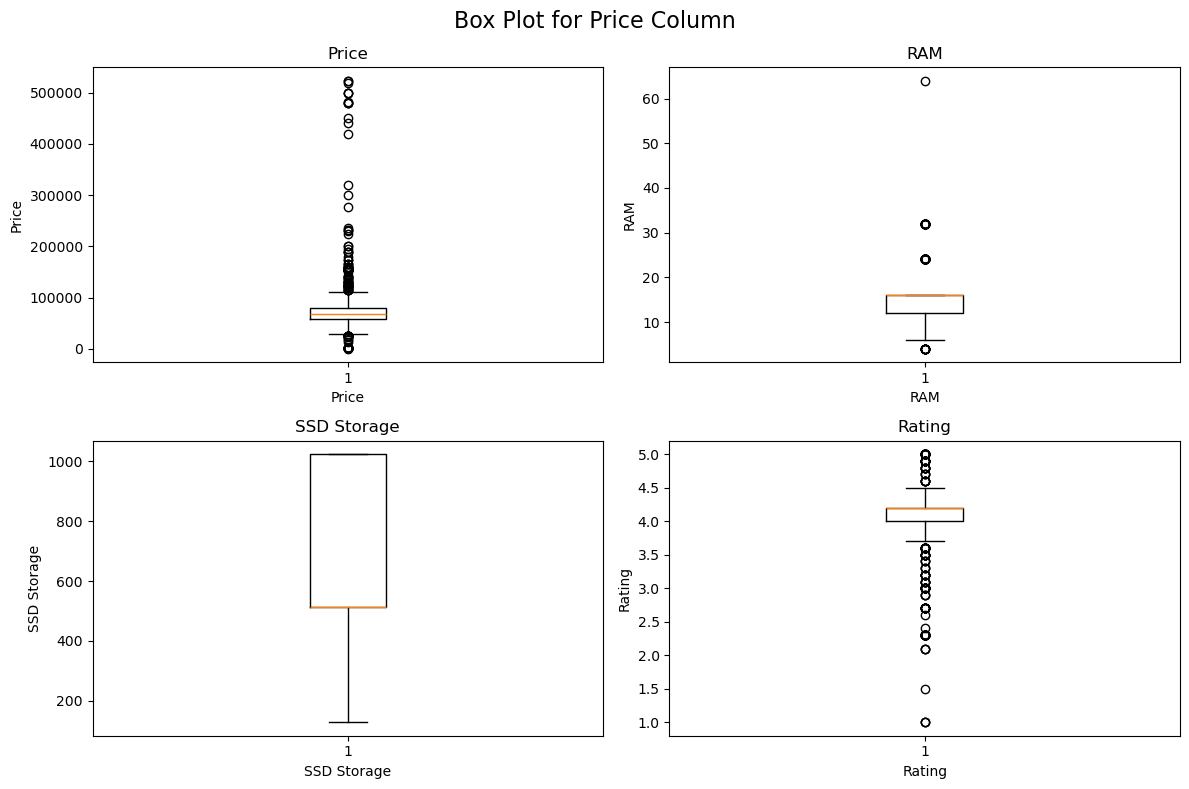

In [30]:
# make the box plot for the price column
import matplotlib.pyplot as plt

# make the subplot
fig,axes = plt.subplots(2,2, figsize=(12,8))

# make the title of the subplot
fig.suptitle("Box Plot for Price Column", fontsize=16)

# make the box plot for the price column
axes[0,0].boxplot(df['Price'].dropna())
axes[0,0].set_title("Price")
axes[0,0].set_xlabel("Price")
axes[0,0].set_ylabel("Price")


axes[0,1].boxplot(df['RAM'].dropna())
axes[0,1].set_title("RAM")
axes[0,1].set_xlabel("RAM")
axes[0,1].set_ylabel("RAM")

axes[1,0].boxplot(df['SSD_Storage'].dropna())
axes[1,0].set_title("SSD Storage")
axes[1,0].set_xlabel("SSD Storage")
axes[1,0].set_ylabel("SSD Storage")

axes[1,1].boxplot(df['Rating'].dropna())
axes[1,1].set_title("Rating")
axes[1,1].set_xlabel("Rating")
axes[1,1].set_ylabel("Rating")

plt.tight_layout()
plt.show()



In [31]:
# ram column of mean median and mode
ram_mean = df['RAM'].mean()
ram_median = df['RAM'].median()
ram_mode = df['RAM'].mode()[0]

print(f"RAM Mean: {ram_mean}")
print(f"RAM Median: {ram_median}")
print(f"RAM Mode: {ram_mode}")


RAM Mean: 15.315175097276265
RAM Median: 16.0
RAM Mode: 16


In [32]:
# check the missing value in the RAM column
df['RAM'].isnull().sum()

# check the value counts of the RAM column
df['RAM'].value_counts(dropna=False)


RAM
16      483
<NA>    298
8       108
12       59
24       51
32       32
6        24
4        13
64        1
Name: count, dtype: Int64

In [33]:
# handled the missing value with median for three columns price ,ram ,rating  and ssd with mean 

# find the median for the price columns 


df['Price'] = df['Price'].fillna(df['Price'].median(),axis = 0)

df['RAM']  = df['RAM'].fillna(df['RAM'].mode()[0],axis = 0)

df['Rating'] = df['Rating'].fillna(df['Rating'].median(),axis = 0)

df['SSD_Storage'] = df['SSD_Storage'].fillna(int(round(df['SSD_Storage'].mean())), axis=0)

In [34]:
# check the missing value after the handled 
df.isnull().sum()

Price            0
Brand            0
RAM              0
SSD_Storage      0
Color          329
Processor      365
OS             274
Rating           0
dtype: int64

In [35]:
# find the mode of color and processor and os columns
mode_color = df['Color'].mode()[0]
mode_processor = df['Processor'].mode()[0]
mode_os = df['OS'].mode()[0]


# print the mode of color and processor and os columns
print(f"Mode of Color: {mode_color}")
print(f"Mode of Processor: {mode_processor}")
print(f"Mode of OS: {mode_os}")


Mode of Color: Grey
Mode of Processor: Intel
Mode of OS: Windows


In [36]:
# fill the missing value of color and processor and os columns with mode
df['Color'] = df['Color'].fillna(mode_color , axis = 0)
df['Processor'] = df['Processor'].fillna(mode_processor , axis = 0)
df['OS'] = df['OS'].fillna(mode_os , axis = 0)


In [37]:
# check the missing value after the handling
df.isnull().sum()

Price          0
Brand          0
RAM            0
SSD_Storage    0
Color          0
Processor      0
OS             0
Rating         0
dtype: int64

In [38]:
# RAM columns unique values
df['RAM'].unique()

<IntegerArray>
[12, 16, 8, 6, 4, 24, 32, 64]
Length: 8, dtype: Int64

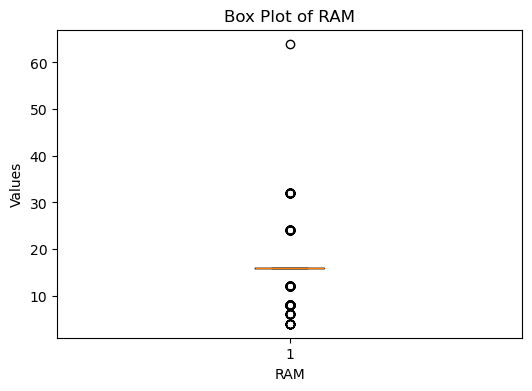

In [39]:
# RAM columns box plot after handling the missing value
plt.figure(figsize=(6,4))
plt.boxplot(df['RAM'])
plt.xlabel('RAM')
plt.ylabel('Values')
plt.title('Box Plot of RAM')
plt.show()

In [40]:
# handled the outlier 

# find the IQR for the RAM column

Q1 = df['RAM'].quantile(0.25)
Q3 = df['RAM'].quantile(0.75)


# calculate the IQR
IQR = Q3 - Q1

# calculate the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# filter the outliers in the RAM column
outliers_ram= df[(df['RAM'] < lower_bound) | (df['RAM'] > upper_bound)]
print("Outliers in RAM column:")
# uniue values of the outliers in the RAM column
print(outliers_ram['RAM'].unique())

Outliers in RAM column:
<IntegerArray>
[12, 8, 6, 4, 24, 32, 64]
Length: 7, dtype: Int64


In [41]:

# Check unique RAM values and their counts
print("Unique RAM values and counts:")
print(df['RAM'].value_counts().sort_index())
print(f"\nTotal rows: {len(df)}")
print(f"\nRAM Mean: {df['RAM'].mean()}")
print(f"RAM Median: {df['RAM'].median()}")
print(f"RAM Mode: {df['RAM'].mode()[0]}")
print(f"\n--- Outlier Bounds ---")
print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")


Unique RAM values and counts:
RAM
4      13
6      24
8     108
12     59
16    781
24     51
32     32
64      1
Name: count, dtype: Int64

Total rows: 1069

RAM Mean: 15.506080449017773
RAM Median: 16.0
RAM Mode: 16

--- Outlier Bounds ---
Q1: 16.0
Q3: 16.0
IQR: 0.0
Lower Bound: 16.0
Upper Bound: 16.0


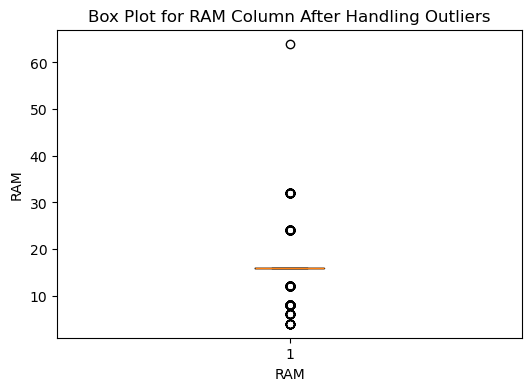

In [42]:
# make the box plot for the RAM column after handling the outliers
plt.figure(figsize=(6,4))
plt.boxplot(df['RAM'])
plt.title("Box Plot for RAM Column After Handling Outliers")
plt.xlabel("RAM")
plt.ylabel("RAM")
plt.show()

# EDA (Exploratory Data Analysis) on the scrap data

In [43]:
df.head()

,Price,Brand,RAM,SSD_Storage,Color,Processor,OS,Rating
0,53990,Acer,12,512,Silver,Intel,Windows,4.0
1,79990,Acer,16,512,Grey,Intel,Windows,4.2
2,45490,Dell,8,639,Black,Intel,Windows,4.1
3,51990,HP,8,512,Silver,Intel,Windows,4.1
4,53990,ASUS,8,639,Blue,Intel,Windows,4.2


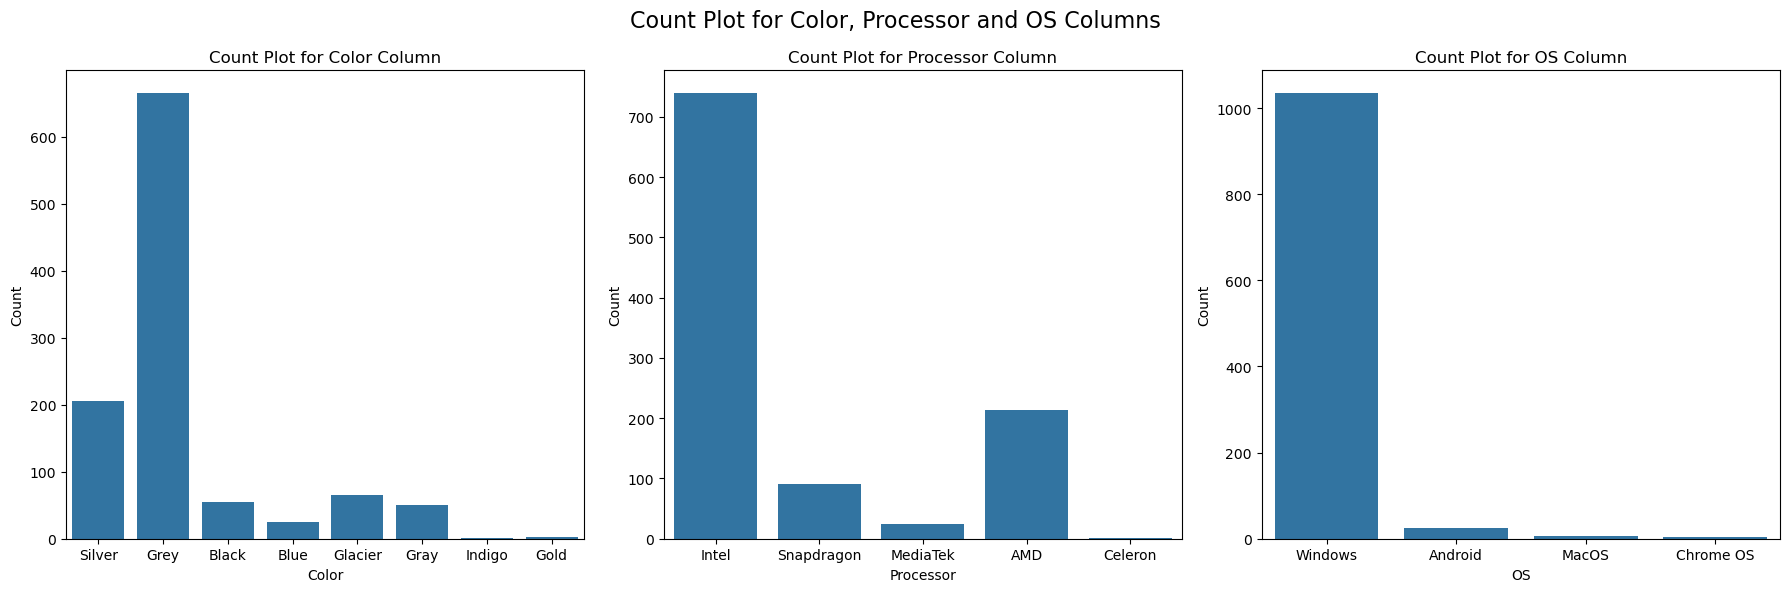

In [44]:
# make the subplot for the color ,processor and os columns

import seaborn as sns
import matplotlib.pyplot as plt

# make the subplots
fig,axes = plt.subplots(1,3, figsize=(18,6))

#make the suptitles for the subplots
fig.suptitle("Count Plot for Color, Processor and OS Columns", fontsize=16) 

# make the count plot for the color column
sns.countplot(data =df,
                x = 'Color',
                ax = axes[0]
                )  
axes[0].set_title("Count Plot for Color Column")
axes[0].set_xlabel("Color")
axes[0].set_ylabel("Count")


# make the count plot for the processor column
sns.countplot(data =df,
                x = 'Processor',
                ax = axes[1]
                )       

axes[1].set_title("Count Plot for Processor Column")
axes[1].set_xlabel("Processor")
axes[1].set_ylabel("Count")


# make the count plot for the os column
sns.countplot(data =df,
                x = 'OS',
                ax = axes[2]
                )
axes[2].set_title("Count Plot for OS Column")
axes[2].set_xlabel("OS")
axes[2].set_ylabel("Count")


plt.tight_layout()
plt.show()



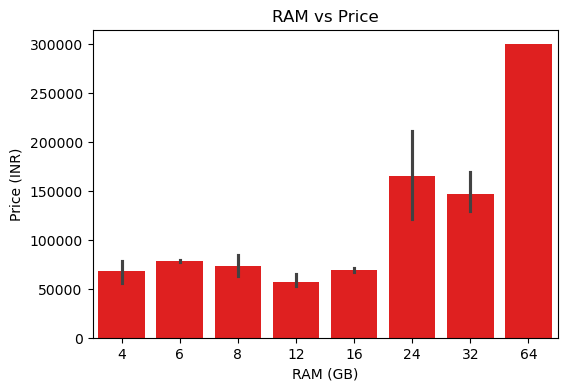

In [45]:
# make the ram vs price bar plot
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='RAM', y='Price',color='red')
plt.title("RAM vs Price")
plt.xlabel("RAM (GB)")
plt.ylabel("Price (INR)")
plt.show()

##### After the RAM VS Price bar plot ,24GB and 64GB RAM price are extreamly high as compared to 8 and 16GB RAM.

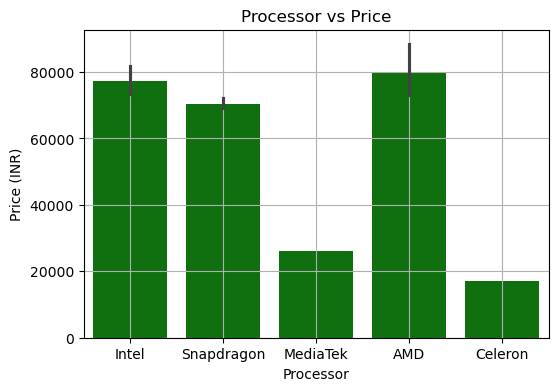

In [46]:
# processor vs price bar plot
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='Processor', y='Price',color='Green')
plt.title("Processor vs Price")
plt.xlabel("Processor")
plt.ylabel("Price (INR)")
plt.grid()
plt.show()


##### After the Processor vs Price plot, AMD, Intel and Snapdragon price are extreamly high as compared to MediaTek and Celeron.

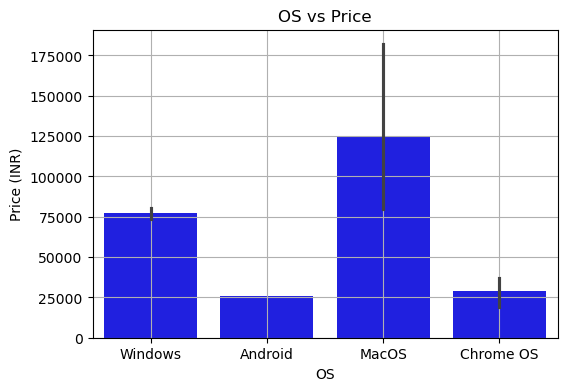

In [47]:
# OS vs price bar plot
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='OS', y='Price',color='Blue')
plt.title("OS vs Price")
plt.xlabel("OS")
plt.ylabel("Price (INR)")
plt.grid()
plt.show()

##### After the OS vs Price plot, Windows and MacOS price are extreamly high as compared to Chrome OS and Android.

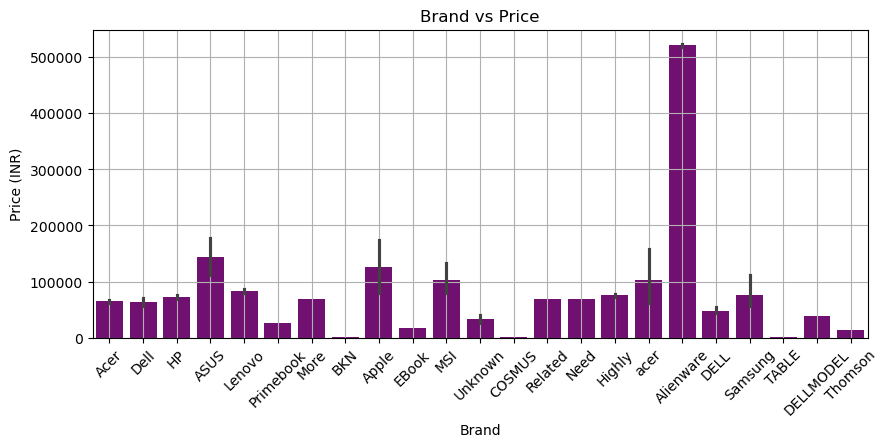

In [48]:
# Brand vs price bar plot
plt.figure(figsize=(10,4))
sns.barplot(data=df, x='Brand', y='Price',color='Purple')
plt.title("Brand vs Price")
plt.xlabel("Brand")
plt.ylabel("Price (INR)")
plt.xticks(rotation=45)
plt.grid()
plt.show()


##### After the Brand vs Price plot, Alienware,Apple and Asus price are extreamly high as compared to Lenovo, HP,Acer and others .

C:\Users\ssart\AppData\Local\Temp\ipykernel_25356\3584850415.py:6: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.barplot(data=df, x='RAM', y='Price', hue='SSD_Storage', palette=colors)


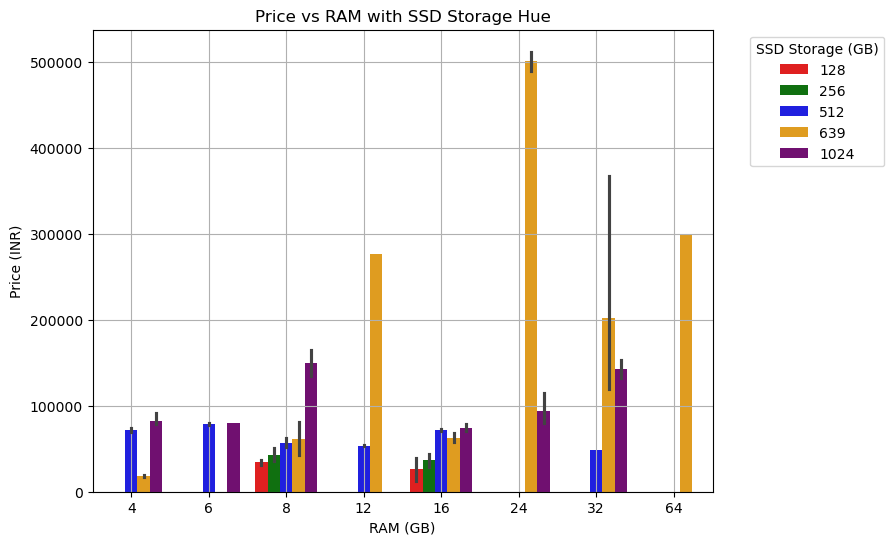

In [49]:
# make the plot for the price vs ram using ssd hue
plt.figure(figsize=(8,6))

# color pallette for the hue manually
colors = ["red", "green", "blue", "orange", "purple", "brown", "pink", "gray", "cyan", "magenta"]
sns.barplot(data=df, x='RAM', y='Price', hue='SSD_Storage', palette=colors)
plt.title("Price vs RAM with SSD Storage Hue")
plt.xlabel("RAM (GB)")
plt.ylabel("Price (INR)")
plt.legend(title='SSD Storage (GB)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

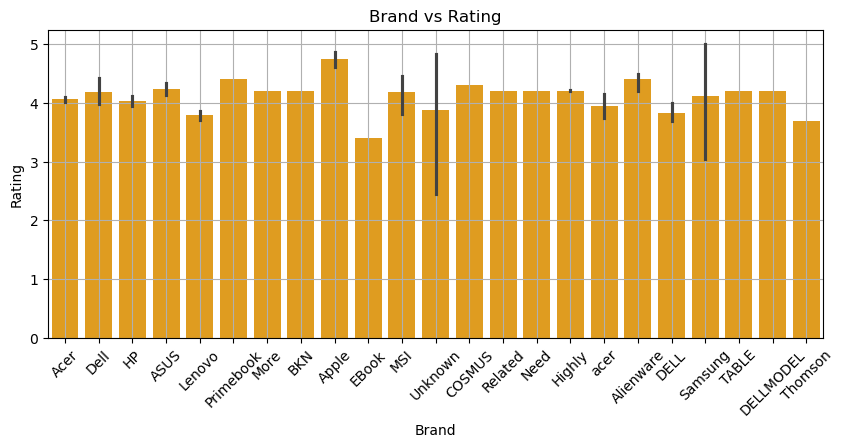

In [50]:
# Brand vs rating bar plot
plt.figure(figsize=(10,4))
sns.barplot(data=df, x='Brand', y='Rating',color='orange')
plt.title("Brand vs Rating")
plt.xlabel("Brand")
plt.ylabel("Rating")
plt.xticks(rotation=45)
plt.grid()
plt.show()

#### After the Brand vs Rating plot, Apple and Alineware rating are extreamly high as compared to Lenovo, HP,Acer and others .

In [51]:
#  final df after cleaning
df.head()

,Price,Brand,RAM,SSD_Storage,Color,Processor,OS,Rating
0,53990,Acer,12,512,Silver,Intel,Windows,4.0
1,79990,Acer,16,512,Grey,Intel,Windows,4.2
2,45490,Dell,8,639,Black,Intel,Windows,4.1
3,51990,HP,8,512,Silver,Intel,Windows,4.1
4,53990,ASUS,8,639,Blue,Intel,Windows,4.2


In [52]:
# make the pie plot for the Rating column

# Calculate the percentage of each rating category
rating_counts = df['Rating'].value_counts()
rating_percentages =(rating_counts / len(df)) * 100
rating_percentages = rating_percentages.round(2)

In [53]:
df['Rating'].value_counts()

Rating
4.2    504
4.0    147
4.1     75
2.3     44
4.3     41
4.4     39
5.0     34
3.6     22
3.7     20
3.0     20
3.8     18
3.9     15
2.7     13
4.9     13
4.5     11
3.5      8
3.2      7
4.8      6
4.6      6
3.1      5
3.4      3
3.3      3
4.7      3
2.1      3
1.0      3
2.9      3
1.5      1
2.4      1
2.6      1
Name: count, dtype: int64

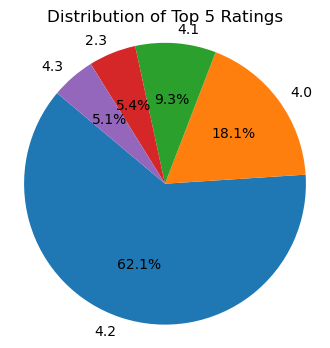

In [54]:
# top five rating pie plot
top_ratings = rating_counts.head(5)
top_ratings_percentages = (top_ratings / len(df)) * 100
top_ratings_percentages = top_ratings_percentages.round(2)

plt.figure(figsize=(4,4))
plt.pie(top_ratings_percentages,
        labels=top_ratings.index,
        autopct='%1.1f%%', 
        startangle=140
    )

plt.title("Distribution of Top 5 Ratings")
plt.axis('equal')
plt.show()


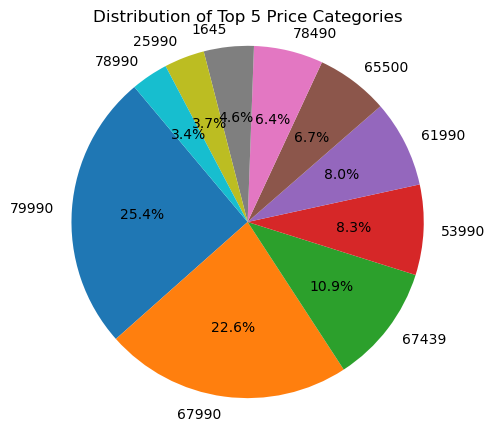

In [55]:
# check the top five price laptops pie plot

# Calculate the percentage of each price category
price_counts = df['Price'].value_counts().head(10)
price_percentages = (price_counts / len(df)) * 100
price_percentages = price_percentages.round(2)

plt.figure(figsize=(5,5))
plt.pie(price_percentages,
        labels=price_counts.index,
        autopct='%1.1f%%', 
        startangle=130
    )
plt.title("Distribution of Top 5 Price Categories")
plt.axis('equal')
plt.show()

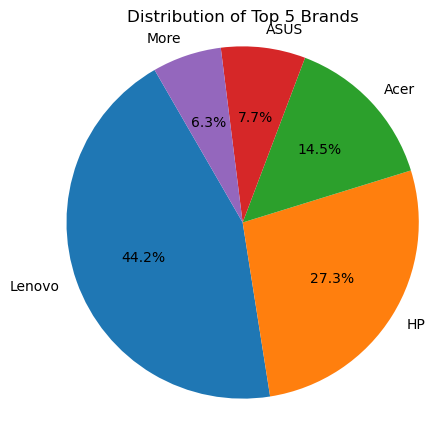

In [56]:
# check the top 5 brands make the pie plot
# Calculate the percentage of each brand category
brand_counts = df['Brand'].value_counts().head(5)
brand_percentages = (brand_counts / len(df)) * 100
brand_percentages = brand_percentages.round(2)

plt.figure(figsize=(5,5))
plt.pie(brand_percentages,
        labels=brand_counts.index,
        autopct='%1.1f%%', 
        startangle=120
    )

plt.title("Distribution of Top 5 Brands")
plt.axis('equal')
plt.show()

In [57]:
# saved the clean dataset

df.to_csv("Clean Dataset.csv",index=False)
